In [7]:
import zipfile
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
plt.style.use(['default', 'science'])

from code_utils.utils_basic import PROJECT_PATH

In [8]:
def load_csv_from_zip(zip_path, csv_path, **kwargs):
    """
    Load a CSV file from a ZIP archive into a pandas DataFrame.
    """
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open(csv_path) as f:
            df = pd.read_csv(f, **kwargs)
    return df

# 1. Load data

In [9]:
col_li = [
    'in_degree_centrality',
    'out_degree_centrality',
    'closeness_centrality',
    'betweenness_centrality',
    'in_eigenvector_centrality', 'out_eigenvector_centrality',
    'in_katz_centrality', 'out_katz_centrality',
    'pagerank',
    'clustering_coefficient']

label_li = {
    'in_degree_centrality'       : 'In-degree centrality',
    'out_degree_centrality'      : 'Out-degree centrality',
    'closeness_centrality'       : 'Closeness centrality',
    'betweenness_centrality'     : 'Betweenness centrality',
    'in_eigenvector_centrality'  : 'In-eigenvector centrality',
    'out_eigenvector_centrality' : 'Out-eigenvector centrality',
    'in_katz_centrality'         : 'In-Katz centrality',
    'out_katz_centrality'        : 'Out-Katz centrality',
    'pagerank'                   : 'PageRank',
    'clustering_coefficient'     : 'Clustering coefficient',
}

In [10]:
zip_path = PROJECT_PATH / 'data/dataset.zip'

# L-space node degree
l_space = load_csv_from_zip(
    zip_path,
    csv_path = 'space_l.csv',
    index_col = 0, header = 0,
    dtype = {'pt_code': str})

# P-space node degree
p_space = load_csv_from_zip(
    zip_path,
    csv_path = 'space_p.csv',
    index_col=0, header=0,
    dtype = {'pt_code': str})


print('\nData info:',
    '\nData shape:', l_space.shape, p_space.shape,
    '\nColumns:', l_space.columns.tolist(), p_space.columns.tolist(),
    '\nNA values:', l_space.isna().sum().sum(), p_space.columns.tolist(),)


l_space = (l_space[col_li]
    .copy()
    .rename(columns=label_li))

p_space = (p_space[col_li]
    .copy()
    .rename(columns=label_li))


Data info: 
Data shape: (4327, 18) (4327, 18) 
Columns: ['in_degree_centrality', 'out_degree_centrality', 'closeness_centrality', 'betweenness_centrality', 'in_eigenvector_centrality', 'out_eigenvector_centrality', 'in_katz_centrality', 'out_katz_centrality', 'pagerank', 'clustering_coefficient', 'label', 'BUS', 'COM', 'EDU', 'OPS', 'REC', 'RES', 'TRS'] ['in_degree_centrality', 'out_degree_centrality', 'closeness_centrality', 'betweenness_centrality', 'in_eigenvector_centrality', 'out_eigenvector_centrality', 'in_katz_centrality', 'out_katz_centrality', 'pagerank', 'clustering_coefficient', 'label', 'BUS', 'COM', 'EDU', 'OPS', 'REC', 'RES', 'TRS'] 
NA values: 0 ['in_degree_centrality', 'out_degree_centrality', 'closeness_centrality', 'betweenness_centrality', 'in_eigenvector_centrality', 'out_eigenvector_centrality', 'in_katz_centrality', 'out_katz_centrality', 'pagerank', 'clustering_coefficient', 'label', 'BUS', 'COM', 'EDU', 'OPS', 'REC', 'RES', 'TRS']


In [11]:
import scipy.stats as stats

def apply_log_transform(data, columns=None):

    data = data.copy()

    if columns is None:
        columns = data.columns.tolist()

    for _col in columns:
        s = pd.to_numeric(data[_col], errors="raise")

        if s.isna().any():
            raise ValueError(f"NaN values found in column '{_col}'.")

        if (s < 0.).any():
            raise ValueError("Non-positive values found in column '{col}'. Log transform is not defined for values <= 0.")

        min_val = np.min(s)

        # Shift data if minimum value is zero
        if min_val == 0.:
            min_val_nonzero = np.min(s[s > 0.])
            s = s + min_val_nonzero

        # Apply log transform
        data[_col] = np.log(s)

    return data
# =========================================================================
def corrfunc(x, y, **kws):
    """
    Annotate a seaborn pairplot panel with Pearson correlation coefficient
    and significance stars.

    Parameters
    ----------
    x, y : array-like
        Input data vectors.
    **kws :
        Ignored keyword arguments (for seaborn compatibility).
    """
    # Pearson correlation
    r, p_value = stats.pearsonr(x, y)

    # Color based on strength of correlation
    color = "red" if abs(r) >= 0.94 else "black"

    # Significance stars
    if p_value <= 0.01:
        sig = "***"
    elif p_value < 0.05:
        sig = "**"
    elif p_value < 0.1:
        sig = "*"
    else:
        sig = ""

    ax = plt.gca()

    # Format annotation text
    # Use parentheses to avoid ambiguity: (rho)^{***}
    text = rf"$\rho = {r:.3f}^{{{sig}}}$"

    ax.annotate(
        text,
        xy = (0.05, 0.95),
        xycoords = ax.transAxes,
        fontsize = 8,
        color = color,
        ha = "left", va="top",
    )
# =========================================================================

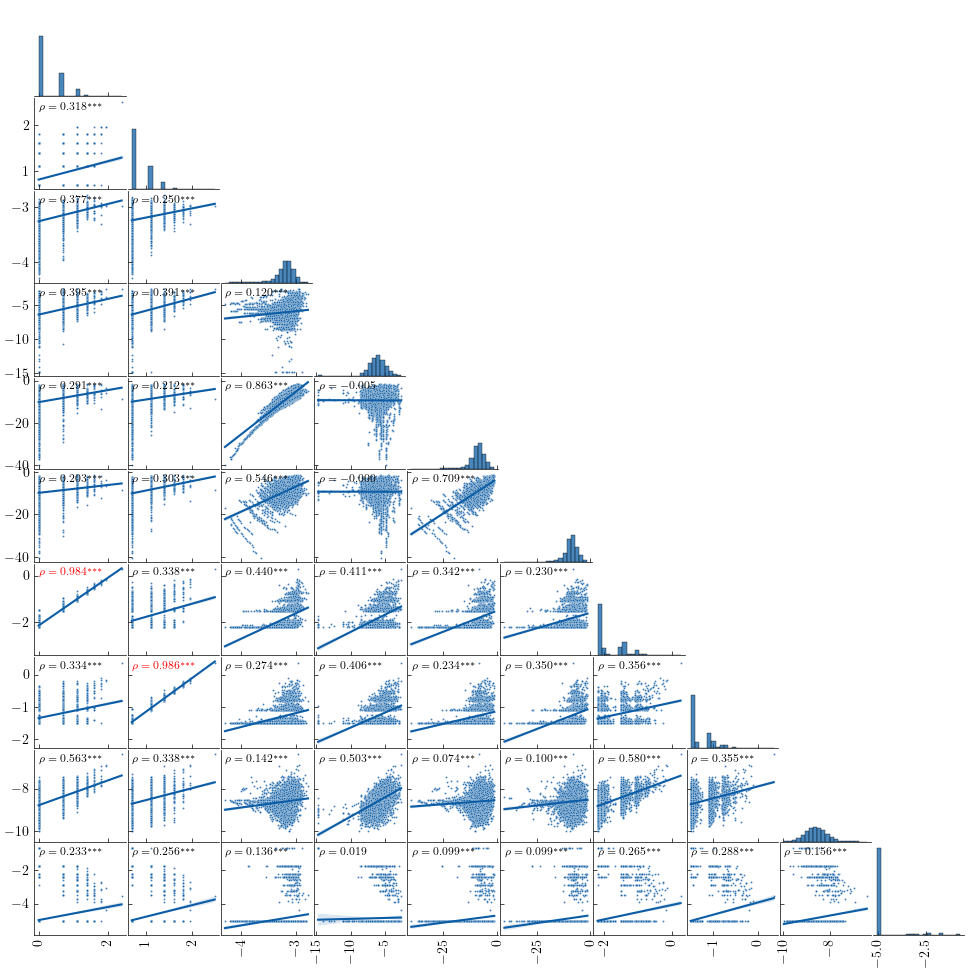

In [12]:
space_type = 'l_space'


if space_type == 'l_space':
    data = l_space
elif space_type == 'p_space':
    data = p_space


grids = sns.pairplot(
    data,
    height = 1.0,
    corner = True, kind = 'reg',
    diag_kind = 'hist',
    diag_kws = {
        'bins' : 20},
    plot_kws = {
        'x_ci' : 'ci',
        'fit_reg' : True,
        'scatter_kws' : {
            's' : 2,
            'alpha' : 0.8,
            'marker' : 'o',
            'edgecolor' : 'white',
            'linewidths' : 0.2
        } }
    )

grids = grids.map_lower(corrfunc)

#
axes = grids.axes.flatten()
for ax in axes:
    if ax is None:
        continue
    ax.tick_params(axis='both', which='minor', top=False, right=False, left=False, bottom=False)
    ax.tick_params(axis='both', which='major', top=False, right=False)
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_xlabel(None)
    ax.set_ylabel(None)

plt.tight_layout()

# adjust spacing
grids.fig.subplots_adjust(
    wspace=0.02,  # horizontal spacing
    hspace=0.02   # vertical spacing
)

# Save figure
# plt.savefig(f'feature_correlation_{space_type}_with_label.pdf',
#     bbox_inches = 'tight',)
# plt.savefig(f'feature_correlation_{space_type}.jpg',
#     bbox_inches = 'tight', dpi=600,)